HACKULATOR RESULTS - REALISTIC CLOCK MANAGEMENT
Over 30s: they milk clock | 30s or under: they hold ball
Scenario                  Decision     Do not Foul    Foul         Advantage
----------------------------------------------------------------------
Down 6, 70s, 70% FT       DON'T FOUL   0.00867        0.00516      0.00351
Down 5, 60s, 70% FT       FOUL         0.00200        0.02117      0.01917
Down 7, 80s, 70% FT       FOUL         0.00000        0.00102      0.00102
Down 8, 90s, 70% FT       FOUL         0.00000        0.00177      0.00177
Down 9, 100s, 70% FT      FOUL         0.00067        0.00090      0.00023

30-SECOND THRESHOLD ANALYSIS
35s: DON'T FOUL - Do not Foul 0.08767, Foul 0.03647
32s: DON'T FOUL - Do not Foul 0.05733, Foul 0.03933
30s: FOUL - Do not Foul 0.00000, Foul 0.03692
28s: FOUL - Do not Foul 0.00000, Foul 0.03556
25s: FOUL - Do not Foul 0.00000, Foul 0.03582


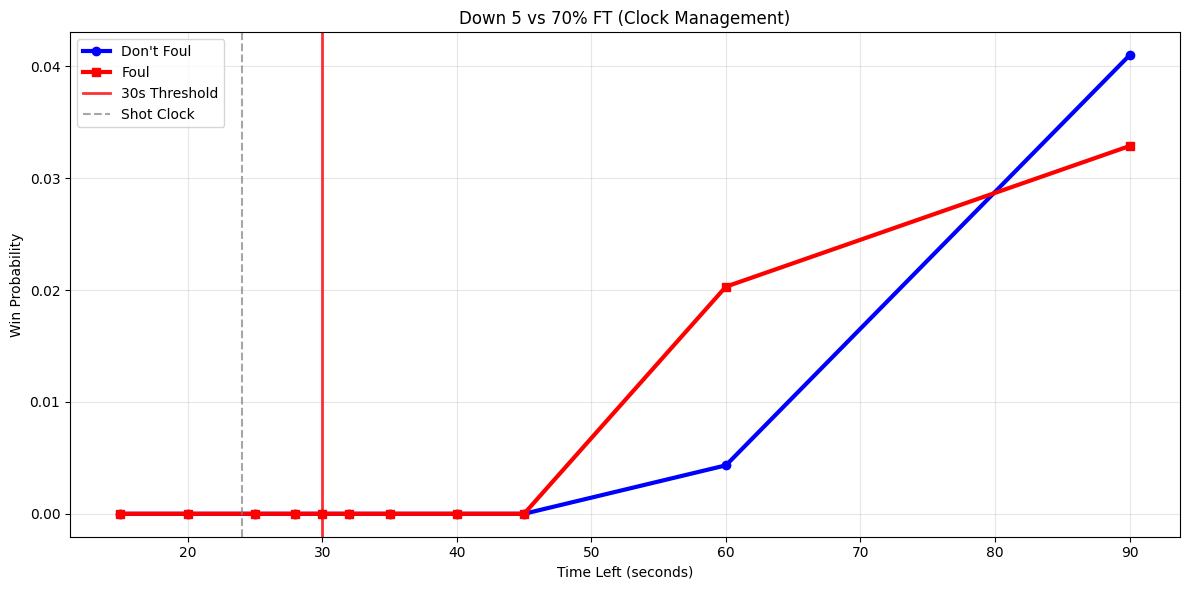

In [6]:
# THE HACKULATOR - Basketball Fouling Decision Tool
import numpy as np
import matplotlib.pyplot as plt

# NBA Parameters
LEAGUE_AVG_FT_PCT = 0.76
FT_OREB_RATE = 0.186  # 18.6% from article
SHOT_CLOCK = 30
TURNOVER_RATE = 0.10  # 10% chance of turnover per possession

# Shooting parameters
OUR_3PT_RATE = 0.40       # Our 3pt attempt rate when behind
OUR_3PT_PCT = 0.35        # Our 3pt percentage
OUR_2PT_PCT = 0.50        # Our 2pt percentage
THEIR_3PT_RATE = 0.35     # Their 3pt attempt rate  
THEIR_3PT_PCT = 0.35      # Their 3pt percentage
THEIR_2PT_PCT = 0.50      # Their 2pt percentage

def simulate_game_with_clock_management(time_left_seconds, points_behind, we_control_pace=False):
    """
    Simulate game with realistic clock management:
    - Over 30s: they milk clock (20-30s per possession)
    - 30s or under: they just hold ball and don't shoot
    """
    num_simulations = 3000
    wins = 0
    
    for _ in range(num_simulations):
        our_score = 0
        their_score = 0
        remaining_time = float(time_left_seconds)
        
        while remaining_time > 5:  # Need minimum time for any action
            if we_control_pace:
                # We go first - 8-18 seconds
                planned_time = np.random.uniform(8, min(18, remaining_time))
                
                # Check for turnover at random point during our possession
                if np.random.random() < TURNOVER_RATE:
                    # Turnover happens at random time during possession
                    turnover_time = np.random.uniform(2, min(planned_time, remaining_time))
                    remaining_time -= turnover_time
                else:
                    # Complete possession and shoot
                    remaining_time -= planned_time
                    
                    # Our shot
                    current_deficit = points_behind + their_score - our_score
                    if current_deficit >= 6:
                        three_rate = 0.7
                    elif current_deficit >= 3:
                        three_rate = 0.6
                    else:
                        three_rate = OUR_3PT_RATE
                        
                    if np.random.random() < three_rate:
                        if np.random.random() < OUR_3PT_PCT:
                            our_score += 3
                    else:
                        if np.random.random() < OUR_2PT_PCT:
                            our_score += 2
                
                # Their turn
                if remaining_time > 30:
                    # They milk clock: 20-30 seconds
                    planned_time = np.random.uniform(20, min(30, remaining_time))
                    
                    # Check for their turnover at random point
                    if np.random.random() < TURNOVER_RATE:
                        turnover_time = np.random.uniform(2, min(planned_time, remaining_time))
                        remaining_time -= turnover_time
                    else:
                        # Complete possession and shoot
                        remaining_time -= planned_time
                        
                        # Their shot
                        if np.random.random() < THEIR_3PT_RATE:
                            if np.random.random() < THEIR_3PT_PCT:
                                their_score += 3
                        else:
                            if np.random.random() < THEIR_2PT_PCT:
                                their_score += 2
                elif remaining_time > 5:
                    # 30s or under - they just hold the ball, don't shoot
                    remaining_time = 0  # They run out the clock
                else:
                    break
                    
            else:
                # They control pace - they go first
                if remaining_time > 30:
                    # They milk clock: 20-30 seconds
                    planned_time = np.random.uniform(20, min(30, remaining_time))
                    
                    # Check for their turnover at random point
                    if np.random.random() < TURNOVER_RATE:
                        turnover_time = np.random.uniform(2, min(planned_time, remaining_time))
                        remaining_time -= turnover_time
                    else:
                        # Complete possession and shoot
                        remaining_time -= planned_time
                        
                        # Their shot
                        if np.random.random() < THEIR_3PT_RATE:
                            if np.random.random() < THEIR_3PT_PCT:
                                their_score += 3
                        else:
                            if np.random.random() < THEIR_2PT_PCT:
                                their_score += 2
                    
                    # Our turn if enough time
                    if remaining_time > 8:
                        planned_time = np.random.uniform(8, min(18, remaining_time))
                        
                        # Check for our turnover at random point
                        if np.random.random() < TURNOVER_RATE:
                            turnover_time = np.random.uniform(2, min(planned_time, remaining_time))
                            remaining_time -= turnover_time
                        else:
                            # Complete possession and shoot
                            remaining_time -= planned_time
                            
                            # Our shot
                            current_deficit = points_behind + their_score - our_score
                            if current_deficit >= 6:
                                three_rate = 0.7
                            elif current_deficit >= 3:
                                three_rate = 0.6
                            else:
                                three_rate = OUR_3PT_RATE
                                
                            if np.random.random() < three_rate:
                                if np.random.random() < OUR_3PT_PCT:
                                    our_score += 3
                            else:
                                if np.random.random() < OUR_2PT_PCT:
                                    our_score += 2
                    else:
                        break
                else:
                    # 30s or under - they just hold the ball, game over
                    remaining_time = 0
                    break
        
        # Check if we won
        if our_score >= points_behind + their_score:
            wins += 1
    
    return wins / num_simulations

def hackulator(points_behind, time_left_seconds, opp_ft_pct=0.76):
    """The Hackulator with realistic late-game clock management"""
    
    # DON'T FOUL scenario - they control pace and clock
    baseline_win_prob = simulate_game_with_clock_management(time_left_seconds, points_behind, we_control_pace=False)
    
    # FOUL scenario - calculate FT outcomes
    make_first_prob = opp_ft_pct
    miss_first_prob = 1 - opp_ft_pct
    
    scenarios = [
        ("Make both FTs", make_first_prob * opp_ft_pct, 2, True),
        ("Make 1st, miss 2nd (Dreb)", make_first_prob * (1-opp_ft_pct) * (1-FT_OREB_RATE), 1, True),
        ("Make 1st, miss 2nd (Oreb)", make_first_prob * (1-opp_ft_pct) * FT_OREB_RATE, 1, False),
        ("Miss 1st (Dreb)", miss_first_prob * (1 - FT_OREB_RATE), 0, True),
        ("Miss 1st (Oreb)", miss_first_prob * FT_OREB_RATE, 0, False),
    ]
    
    total_foul_win_prob = 0.0
    
    for desc, prob, points_scored, we_get_ball in scenarios:
        new_deficit = points_behind + points_scored
        time_after_ft = time_left_seconds - 9  # FTs take ~9 seconds
        
        if we_get_ball:
            # We get possession back and control pace
            scenario_win_prob = simulate_game_with_clock_management(time_after_ft, new_deficit, we_control_pace=True)
        else:
            # They keep possession via OReb
            additional_time = np.random.uniform(20, 30)
            extended_time = time_after_ft - additional_time
            scenario_win_prob = simulate_game_with_clock_management(max(0, extended_time), new_deficit, we_control_pace=False)
        
        total_foul_win_prob += prob * scenario_win_prob
    
    recommendation = "FOUL" if total_foul_win_prob > baseline_win_prob else "DON'T FOUL"
    
    return baseline_win_prob, total_foul_win_prob, recommendation

# Test scenarios showing the 30-second threshold effect
test_scenarios = [
    (6, 70, 0.7),   # Just over 30s threshold
    (5, 60, 0.7),   # At 30s threshold
    (7, 80, 0.7),   # Under 30s threshold
    (8, 90, 0.7),   # Well over threshold
    (9, 100, 0.7),   # Large deficit
]

print("HACKULATOR RESULTS - REALISTIC CLOCK MANAGEMENT")
print("=" * 70)
print("Over 30s: they milk clock | 30s or under: they hold ball")
print("=" * 70)
print(f"{'Scenario':<25} {'Decision':<12} {'Do not Foul':<14} {'Foul':<12} {'Advantage'}")
print("-" * 70)

for points, time, ft_pct in test_scenarios:
    baseline, foul_wp, decision = hackulator(points, time, ft_pct)
    advantage = f"{abs(foul_wp - baseline):.5f}"
    
    scenario_desc = f"Down {points}, {time}s, {ft_pct:.0%} FT"
    print(f"{scenario_desc:<25} {decision:<12} {baseline:<14.5f} {foul_wp:<12.5f} {advantage}")

print("\n30-SECOND THRESHOLD ANALYSIS")
print("=" * 30)
for time in [35, 32, 30, 28, 25]:
    baseline, foul_wp, decision = hackulator(3, time, 0.76)
    print(f"{time}s: {decision} - Do not Foul {baseline:.5f}, Foul {foul_wp:.5f}")

# Visualization
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

# Win probability vs time showing 30s threshold
time_range = [15, 20, 25, 28, 30, 32, 35, 40, 45, 60, 90]
scenario_points, scenario_ft = 5, 0.70

baseline_probs = []
foul_probs = []

for time in time_range:
    baseline, foul_wp, _ = hackulator(scenario_points, time, scenario_ft)
    baseline_probs.append(baseline)
    foul_probs.append(foul_wp)

ax.plot(time_range, baseline_probs, label="Don't Foul", linewidth=3, color='blue', marker='o')
ax.plot(time_range, foul_probs, label="Foul", linewidth=3, color='red', marker='s')
ax.axvline(x=30, color='red', linestyle='-', alpha=0.8, linewidth=2, label='30s Threshold')
ax.axvline(x=24, color='gray', linestyle='--', alpha=0.7, label='Shot Clock')
ax.set_xlabel("Time Left (seconds)")
ax.set_ylabel("Win Probability")
ax.set_title(f"Down {scenario_points} vs {scenario_ft:.0%} FT (Clock Management)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

UP 3 FOULING ANALYSIS - WITH FOULING CYCLE

1-and-1 Bonus
------------------------------
FT%    Decision   No Foul    Foul       Advantage
------------------------------
0.5    FOUL       0.88226    0.96840    0.08614
0.6    FOUL       0.88226    0.95020    0.06794
0.7    FOUL       0.88226    0.93830    0.05604
0.8    FOUL       0.88226    0.92240    0.04014
0.9    FOUL       0.88226    0.90430    0.02204

Double Bonus
------------------------------
FT%    Decision   No Foul    Foul       Advantage
------------------------------
0.5    FOUL       0.88226    0.96330    0.08104
0.6    FOUL       0.88226    0.95100    0.06874
0.7    FOUL       0.88226    0.93830    0.05604
0.8    FOUL       0.88226    0.92330    0.04104
0.9    FOUL       0.88226    0.90870    0.02644


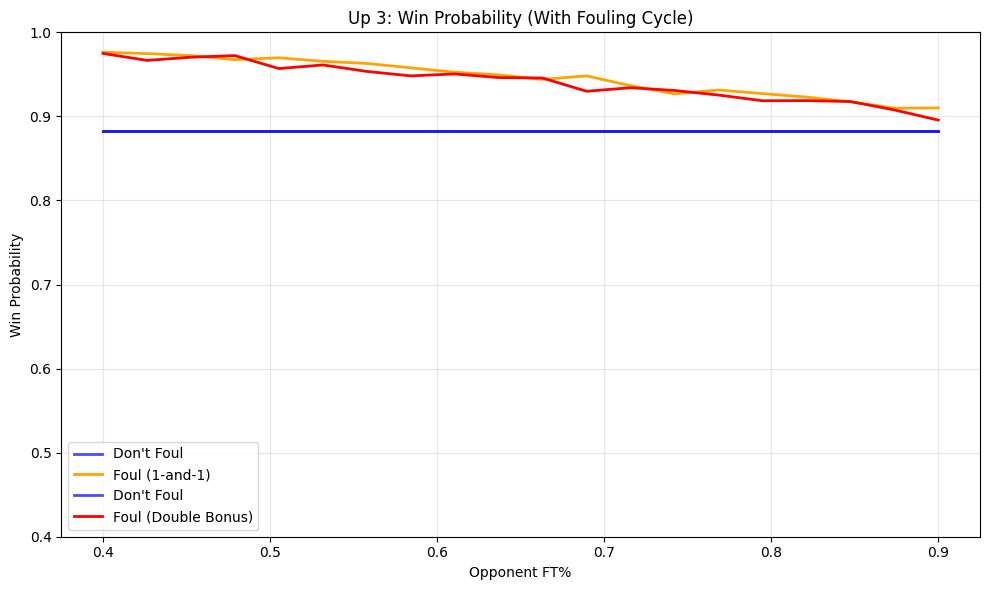

In [11]:
# UP 3 FOULING MODEL - End of game scenario with fouling cycle
import numpy as np
import matplotlib.pyplot as plt

# Parameters for up-3 scenario
THREE_PT_RATE = 0.75  # Probability they attempt a 3-pointer when not fouling
THREE_PT_PCT = 0.35   # 3-point shooting percentage when they attempt one
TWO_PT_PCT = 0.50     # 2-point shooting percentage when they attempt one
OUR_FT_PCT = 0.76     # Our free throw percentage
THEIR_TURNOVER_RATE = 0.15  # Their turnover rate when desperate
OUR_TURNOVER_RATE = 0.12    # Our turnover rate during fouling cycle

def simulate_up3_fouling_cycle(opp_ft_pct, bonus="two_shots", time_left=30):
    """
    Simulate the full fouling cycle when up 3
    """
    num_simulations = 5000
    wins = 0
    
    for _ in range(num_simulations):
        our_lead = 3  # Start up 3
        time_remaining = time_left
        
        # They shoot their free throws
        if bonus == "two_shots":
            # Two guaranteed shots
            if np.random.random() < opp_ft_pct:
                our_lead -= 1
            if np.random.random() < opp_ft_pct:
                our_lead -= 1
        else:  # one_and_one
            if np.random.random() < opp_ft_pct:
                our_lead -= 1
                if np.random.random() < opp_ft_pct:
                    our_lead -= 1
        
        time_remaining -= 6  # FTs take time
        
        # Now simulate the fouling cycle
        while time_remaining > 3 and our_lead > 0:
            if our_lead >= 3:
                # We're up 3+, they might not foul us
                break
            
            # They foul us immediately (down 1 or 2)
            time_remaining -= 3  # Foul takes time
            
            # Check if we turn it over on the inbound (lower chance)
            if np.random.random() < OUR_TURNOVER_RATE * 0.3:  
                time_remaining -= 2
                continue
            
            # We shoot FTs (assume double bonus late in game)
            if np.random.random() < OUR_FT_PCT:
                our_lead += 1
            if np.random.random() < OUR_FT_PCT:
                our_lead += 1
                
            time_remaining -= 6  # Our FTs take time
            
            if time_remaining <= 5:
                break
                
            # They get the ball back, what do they do?
            if our_lead == 1:
                # Down 1, they need any basket
                time_remaining -= np.random.uniform(8, 15)  # Quick shot
                if np.random.random() < THEIR_TURNOVER_RATE:
                    break  # They turn it over, we win
                # They shoot
                if np.random.random() < THREE_PT_RATE:
                    if np.random.random() < THREE_PT_PCT:
                        our_lead -= 3  # They hit 3, now they lead
                else:
                    if np.random.random() < TWO_PT_PCT:
                        our_lead -= 2  # They hit 2, tied
                        
            elif our_lead == 2:
                # Down 2, they need 2+ points
                time_remaining -= np.random.uniform(8, 15)  # Quick shot
                if np.random.random() < THEIR_TURNOVER_RATE:
                    break  # They turn it over, we win
                # They shoot - prefer 3s when down 2
                three_rate_desperate = 0.6
                if np.random.random() < three_rate_desperate:
                    if np.random.random() < THREE_PT_PCT:
                        our_lead -= 3  # They hit 3, now they lead
                else:
                    if np.random.random() < TWO_PT_PCT:
                        our_lead -= 2  # They hit 2, tied
                        
            elif our_lead >= 3:
                # Up 3+, they might not foul
                break
        
        # Determine winner
        if our_lead > 0:
            wins += 1
        elif our_lead == 0:
            wins += 0.5  # Overtime
    
    return wins / num_simulations

def up3_model_realistic(opp_ft_pct, bonus="two_shots", time_left=30):
    """
    Compare don't foul vs foul scenarios with full fouling cycle simulation
    """
    
    # DON'T FOUL scenario - their turnover rate only applies here
    make_3_prob = THREE_PT_RATE * THREE_PT_PCT
    make_2_prob = (1 - THREE_PT_RATE) * TWO_PT_PCT
    miss_prob = 1 - make_3_prob - make_2_prob
    
    # Add turnover possibility when they have the ball
    turnover_prob = THEIR_TURNOVER_RATE
    adjusted_make_3 = make_3_prob * (1 - turnover_prob)
    adjusted_make_2 = make_2_prob * (1 - turnover_prob)  
    adjusted_miss = miss_prob * (1 - turnover_prob)
    
    # They make 3 (tied) -> overtime
    win_if_they_make_3 = 0.5
    
    # They make 2 (we lead by 1) -> they need steal + score  
    our_turnover_rate = 0.15
    they_score_if_steal = THREE_PT_RATE * THREE_PT_PCT + (1-THREE_PT_RATE) * TWO_PT_PCT
    win_if_they_make_2 = 1 - (our_turnover_rate * they_score_if_steal)
    
    # They miss or turn it over -> we win
    win_if_they_miss_or_turnover = 1.0
    
    dont_foul_win_prob = (adjusted_make_3 * win_if_they_make_3 + 
                         adjusted_make_2 * win_if_they_make_2 + 
                         (adjusted_miss + turnover_prob) * win_if_they_miss_or_turnover)
    
    # FOUL scenario - use full simulation (includes our turnover rate)
    foul_win_prob = simulate_up3_fouling_cycle(opp_ft_pct, bonus, time_left)
    
    return dont_foul_win_prob, foul_win_prob

# Analysis by bonus situation
print("UP 3 FOULING ANALYSIS - WITH FOULING CYCLE")
print("=" * 60)

for bonus_name, bonus_type in [("1-and-1 Bonus", "one_and_one"), ("Double Bonus", "two_shots")]:
    print(f"\n{bonus_name}")
    print("-" * 30)
    print(f"{'FT%':<6} {'Decision':<10} {'No Foul':<10} {'Foul':<10} {'Advantage'}")
    print("-" * 30)
    
    for ft_pct in [0.5, 0.6, 0.7, 0.8, 0.9]:
        no_foul_win, foul_win = up3_model_realistic(ft_pct, bonus_type)
        decision = "FOUL" if foul_win > no_foul_win else "DON'T"
        advantage = abs(foul_win - no_foul_win)
        print(f"{ft_pct:<6.1f} {decision:<10} {no_foul_win:<10.5f} {foul_win:<10.5f} {advantage:.5f}")

# Visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ft_vals = np.linspace(0.4, 0.9, 20)  # Fewer points since simulation is slower

for bonus_name, bonus_type, color in [("1-and-1", "one_and_one", "orange"), ("Double Bonus", "two_shots", "red")]:
    no_foul_wins = []
    foul_wins = []
    
    for ft in ft_vals:
        nf, f = up3_model_realistic(ft, bonus_type)
        no_foul_wins.append(nf)
        foul_wins.append(f)
    
    ax.plot(ft_vals, no_foul_wins, label="Don't Foul", linewidth=2, color='blue', alpha=0.7)
    ax.plot(ft_vals, foul_wins, label=f"Foul ({bonus_name})", linewidth=2, color=color)

ax.set_xlabel("Opponent FT%")
ax.set_ylabel("Win Probability")
ax.set_title("Up 3: Win Probability (With Fouling Cycle)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0.4, 1.0)

plt.tight_layout()
plt.show()

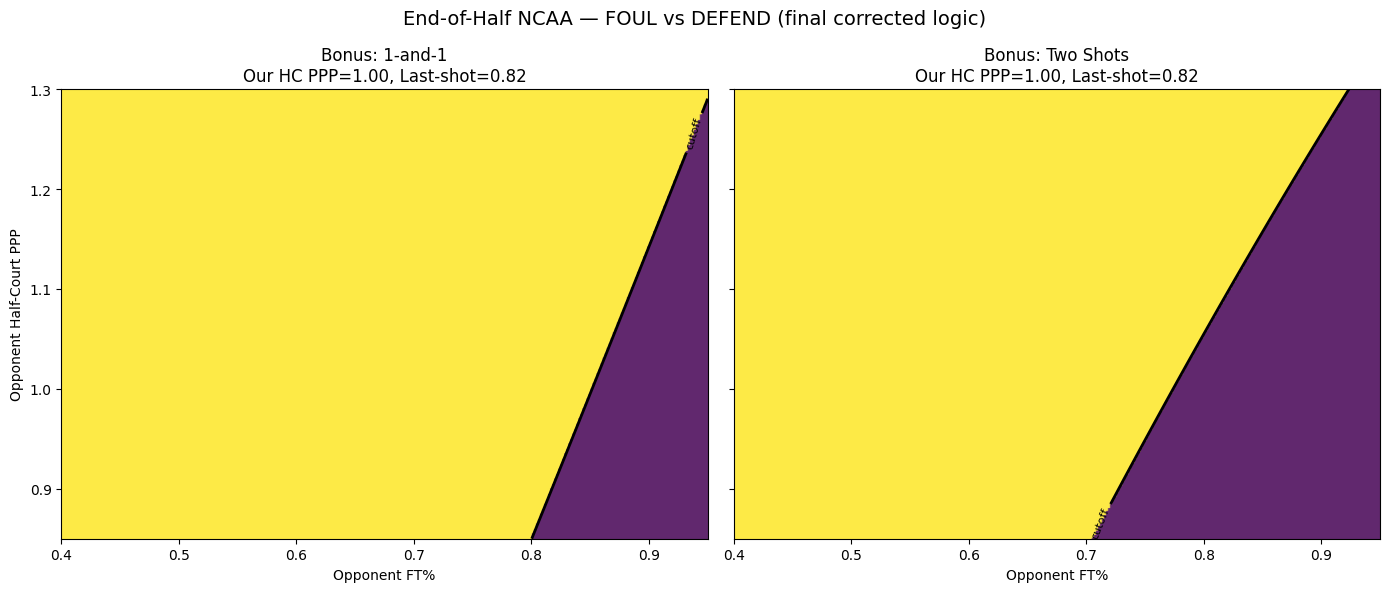

In [12]:
import numpy as np
import matplotlib.pyplot as plt

OUR_FIXED_HC_PPP = 1.0
LATE_FACTOR      = 0.82
FT_OFF_REB       = 0.14 #NBA average off fts

OPP_FT_MIN, OPP_FT_MAX, OPP_FT_STEPS = 0.40, 0.95, 320
OPP_HC_MIN, OPP_HC_MAX, OPP_HC_STEPS = 0.85, 1.3, 320

def ft_ev(q, bonus="one_and_one", ft_off_reb=0.14, opp_last_shot=0.82):
    if bonus == "two_shots":
        made_fts = 2*q
        # If they miss at least one FT and get the oreb, they get their final shot
        at_least_one_miss = 1 - q*q
        reb_value = at_least_one_miss * ft_off_reb * opp_last_shot
        return made_fts + reb_value
    elif bonus == "one_and_one":
        made_fts = q + q*q  # First + (first made * second made)
        # Miss probability: first miss OR (first made AND second miss)
        miss_prob = (1-q) + q*(1-q)
        reb_value = miss_prob * ft_off_reb * opp_last_shot
        return made_fts + reb_value

def build_map(bonus="one_and_one"):
    ft_vals = np.linspace(OPP_FT_MIN, OPP_FT_MAX, OPP_FT_STEPS)
    opp_hc_vals = np.linspace(OPP_HC_MIN, OPP_HC_MAX, OPP_HC_STEPS)
    FT, OPP_HC = np.meshgrid(ft_vals, opp_hc_vals)

    OUR_LAST = OUR_FIXED_HC_PPP * LATE_FACTOR
    OPP_LAST = OPP_HC * LATE_FACTOR

    # Calculate opponent's expected value from free throws
    opp_ft_ev = ft_ev(FT, bonus=bonus, ft_off_reb=FT_OFF_REB, opp_last_shot=OPP_LAST)
    
    # Calculate probability we get possession back after their FTs
    if bonus == "two_shots":
        at_least_one_miss = 1 - FT*FT
        our_possession_prob = at_least_one_miss * (1 - FT_OFF_REB) + FT*FT
    else:  # one_and_one
        miss_prob = (1-FT) + FT*(1-FT)
        our_possession_prob = miss_prob * (1 - FT_OFF_REB) + FT*FT
    
    # Expected outcomes:
    foul_net = -opp_ft_ev + our_possession_prob * OUR_LAST
    no_foul_net = -OPP_LAST
    
    decision = (foul_net > no_foul_net).astype(float)
    boundary = foul_net - no_foul_net
    return FT, OPP_HC, decision, boundary, OUR_LAST

fig, axes = plt.subplots(1,2, figsize=(14,6), sharex=True, sharey=True)

for ax, bonus in zip(axes, ["one_and_one","two_shots"]):
    FT, OPP_HC, decision, boundary, OUR_LAST = build_map(bonus)
    im = ax.imshow(decision, origin="lower",
                   extent=[OPP_FT_MIN, OPP_FT_MAX, OPP_HC_MIN, OPP_HC_MAX],
                   aspect="auto", alpha=0.85)
    CS = ax.contour(FT, OPP_HC, boundary, levels=[0], colors="black", linewidths=2)
    ax.clabel(CS, inline=True, fontsize=8, fmt="cutoff")
    label = "1-and-1" if bonus=="one_and_one" else "Two Shots"
    ax.set_title(f"Bonus: {label}\nOur HC PPP={OUR_FIXED_HC_PPP:.2f}, Last-shot={OUR_LAST:.2f}")
    ax.set_xlabel("Opponent FT%")
axes[0].set_ylabel("Opponent Half-Court PPP")
plt.suptitle("End-of-Half NCAA — FOUL vs DEFEND (final corrected logic)", fontsize=14)
plt.tight_layout()
plt.show()